In [10]:
from numpy import loadtxt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
import pandas as pd



In [13]:
dataset = pd.read_csv("pima-indians-diabetes.csv")


In [14]:
dataset.shape


(767, 9)

In [15]:
dataset.describe()


,6,148,72,35,0,33.6,0.627,50,1
count,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000
mean,3.842243,120.859192,69.101695,20.517601,79.903520,31.990482,0.471674,33.219035,0.348110
std,3.370877,31.978468,19.368155,15.954059,115.283105,7.889091,0.331497,11.752296,0.476682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,32.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.500000,36.600000,0.625000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X, y = make_regression(
    n_samples=100, n_features=10, n_informative=5, n_targets=1, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
y_pred1 = gbr.predict(X_test)
print("Gradient Boosting - R2: ", r2_score(y_test, y_pred1))


Gradient Boosting - R2:  0.9440385915252202


In [17]:
from xgboost import XGBRegressor
xgbr = XGBRegressor()
xgbr.fit(X_train,y_train)

y_pred2 = xgbr.predict(X_test)
print("XGBoost - R2: ", r2_score(y_test, y_pred2))


XGBoost - R2:  0.8766100974882315


In [18]:
from sklearn.ensemble import AdaBoostRegressor

adr = AdaBoostRegressor()

adr.fit(X_train, y_train)

y_pred3 = adr.predict(X_test)
print("AdaBoost - R2: ", r2_score(y_test, y_pred3))


AdaBoost - R2:  0.8436322259835249


In [20]:
from catboost import CatBoostRegressor

cbr = CatBoostRegressor(
  iterations=100,
  depth=5,
  learning_rate=0.01,
  loss_function='RMSE',
  verbose=0

)

cbr.fit(X_train, y_train)
y_pred4 = cbr.predict(X_test)
print("CatBoost - R2: ", r2_score(y_test, y_pred4))


CatBoost - R2:  0.43143633684091154


In [22]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
lgr = LGBMRegressor()
lgr.fit(X_train, y_train)
y_pred5 = lgr.predict(X_test)
print("LightGBM - R2: ", r2_score(y_test, y_pred5))



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 284
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 10
[LightGBM] [Info] Start training from score 8.057860
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

Text(0, 0.5, 'y_pred')

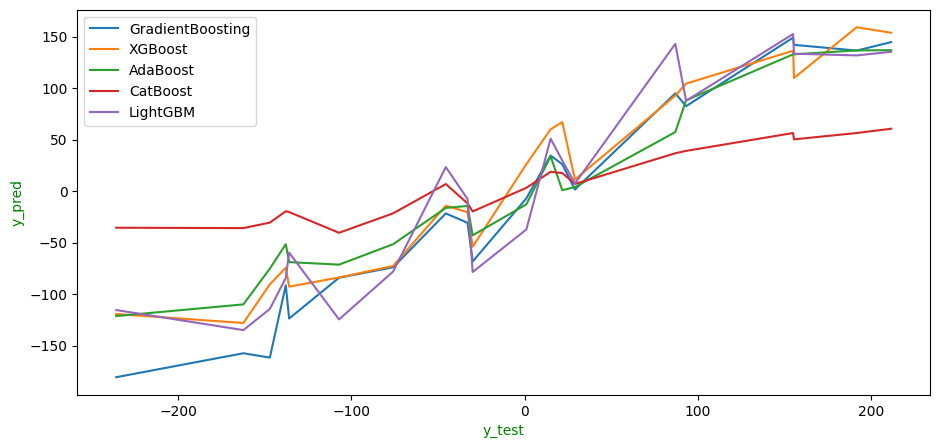

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 5))

ax = sns.lineplot(x=y_test, y=y_pred1, label="GradientBoosting")
ax1 = sns.lineplot(x=y_test, y=y_pred2, label="XGBoost")
ax2 = sns.lineplot(x=y_test, y=y_pred3, label="AdaBoost")
ax3 = sns.lineplot(x=y_test, y=y_pred4, label="CatBoost")
ax4 = sns.lineplot(x=y_test, y=y_pred5, label="LightGBM")

ax.set_xlabel("y_test", color="g")
ax.set_ylabel("y_pred", color="g")
